# Previsão de Rendimento de Safra com Machine Learning

## FarmTech Solutions — Fazenda de 200 Hectares

### Introdução

Este notebook faz parte do projeto da **FarmTech Solutions**, uma empresa de tecnologia agrícola que gerencia uma fazenda de 200 hectares. O objetivo principal é utilizar técnicas de **Machine Learning** para prever o rendimento de safras (em toneladas por hectare) com base em variáveis climáticas e no tipo de cultura plantada.

O dataset contém **155 registros** de 4 tipos de cultura:
- Cocoa, beans (Cacau)
- Rice, paddy (Arroz)
- Rubber, natural (Borracha natural)
- Oil palm fruit (Fruto de palma de óleo)

As variáveis preditoras incluem dados climáticos como precipitação, umidade específica, umidade relativa e temperatura. A variável alvo é o **Yield** (rendimento em toneladas por hectare).

### Etapas do projeto:
1. Análise Exploratória de Dados (EDA)
2. Clusterização (Aprendizado Não Supervisionado)
3. Pré-processamento dos dados
4. Construção de 5 modelos preditivos de regressão
5. Comparação dos modelos
6. Importância das features
7. Conclusões

---
## 1. Setup e Importação de Bibliotecas

Importamos todas as bibliotecas necessárias para análise de dados, visualização e modelagem.

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas do scikit-learn para modelagem
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelos de regressão
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Aprendizado não supervisionado
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Suprimir avisos para manter o notebook limpo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

# Configurar exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 2. Carregamento e Análise Exploratória dos Dados (EDA)

Nesta etapa, carregamos o dataset e realizamos uma análise exploratória completa para entender a estrutura, distribuição e relações entre as variáveis.

In [2]:
# Carregar o dataset a partir do arquivo CSV
df = pd.read_csv('crop_yield.csv')

# Exibir as 10 primeiras linhas para inspeção inicial
print('=== Primeiras 10 linhas do dataset ===')
df.head(10)

=== Primeiras 10 linhas do dataset ===


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [3]:
# Verificar a estrutura do dataset: tipos de dados, número de registros e colunas
print('=== Informações do Dataset ===')
df.info()

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [4]:
# Verificar dimensões do dataset
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')
print(f'\nNomes das colunas:')
for col in df.columns:
    print(f'  - {col}')

Número de linhas: 156
Número de colunas: 6

Nomes das colunas:
  - Crop
  - Precipitation (mm day-1)
  - Specific Humidity at 2 Meters (g/kg)
  - Relative Humidity at 2 Meters (%)
  - Temperature at 2 Meters (C)
  - Yield


In [5]:
# Estatísticas descritivas das variáveis numéricas
print('=== Estatísticas Descritivas ===')
df.describe()

=== Estatísticas Descritivas ===


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.00,156.00,156.00,156.00,156.00
mean,2486.50,18.20,84.74,26.18,56153.10
std,289.46,0.29,1.00,0.26,70421.96
min,1934.62,17.54,82.11,25.56,5249.00
25%,2302.99,18.03,84.12,26.02,8327.75
50%,2424.55,18.27,84.85,26.13,18871.00
75%,2718.08,18.40,85.51,26.30,67518.75
max,3085.79,18.70,86.10,26.81,203399.00


In [6]:
# Verificar valores nulos em cada coluna
print('=== Valores Nulos por Coluna ===')
nulos = df.isnull().sum()
print(nulos)
print(f'\nTotal de valores nulos no dataset: {nulos.sum()}')

if nulos.sum() == 0:
    print('\nO dataset não possui valores nulos. Ótimo!')
else:
    print('\nExistem valores nulos que precisam ser tratados.')

=== Valores Nulos por Coluna ===
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Total de valores nulos no dataset: 0

O dataset não possui valores nulos. Ótimo!


In [7]:
# Verificar valores duplicados
duplicados = df.duplicated().sum()
print(f'Número de linhas duplicadas: {duplicados}')

Número de linhas duplicadas: 0


### 2.1 Distribuição dos Tipos de Cultura

Analisamos a quantidade de registros por tipo de cultura para verificar o balanceamento do dataset.

=== Distribuição por Tipo de Cultura ===
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


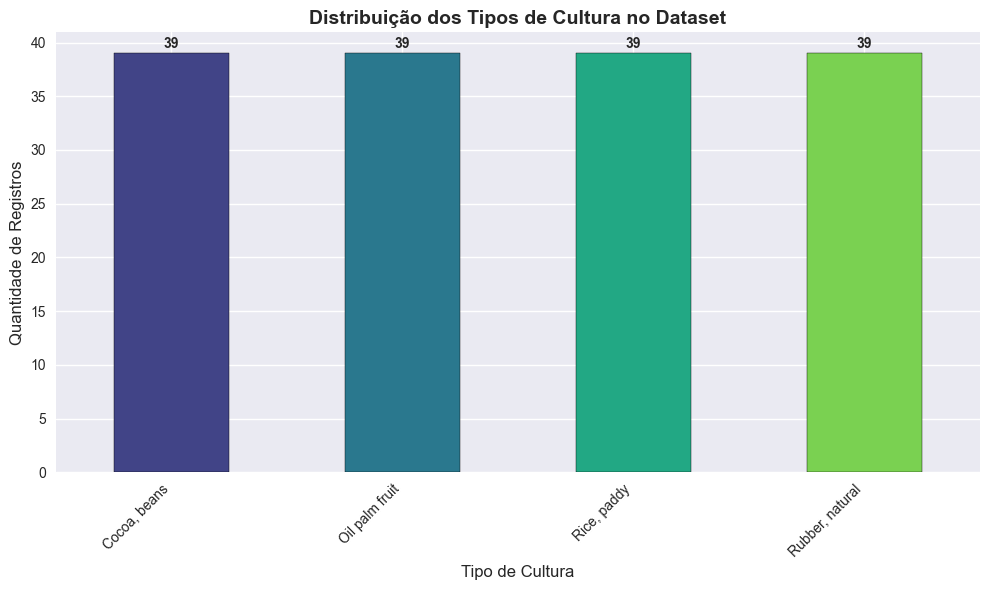

In [8]:
# Contagem de registros por tipo de cultura
print('=== Distribuição por Tipo de Cultura ===')
contagem_culturas = df['Crop'].value_counts()
print(contagem_culturas)

# Gráfico de barras com a distribuição das culturas
fig, ax = plt.subplots(figsize=(10, 6))
cores = sns.color_palette('viridis', n_colors=len(contagem_culturas))
contagem_culturas.plot(kind='bar', color=cores, edgecolor='black', ax=ax)
ax.set_title('Distribuição dos Tipos de Cultura no Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Cultura', fontsize=12)
ax.set_ylabel('Quantidade de Registros', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Adicionar rótulos nas barras
for i, v in enumerate(contagem_culturas.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Distribuição das Variáveis Numéricas

Histogramas para visualizar a distribuição de cada variável numérica.

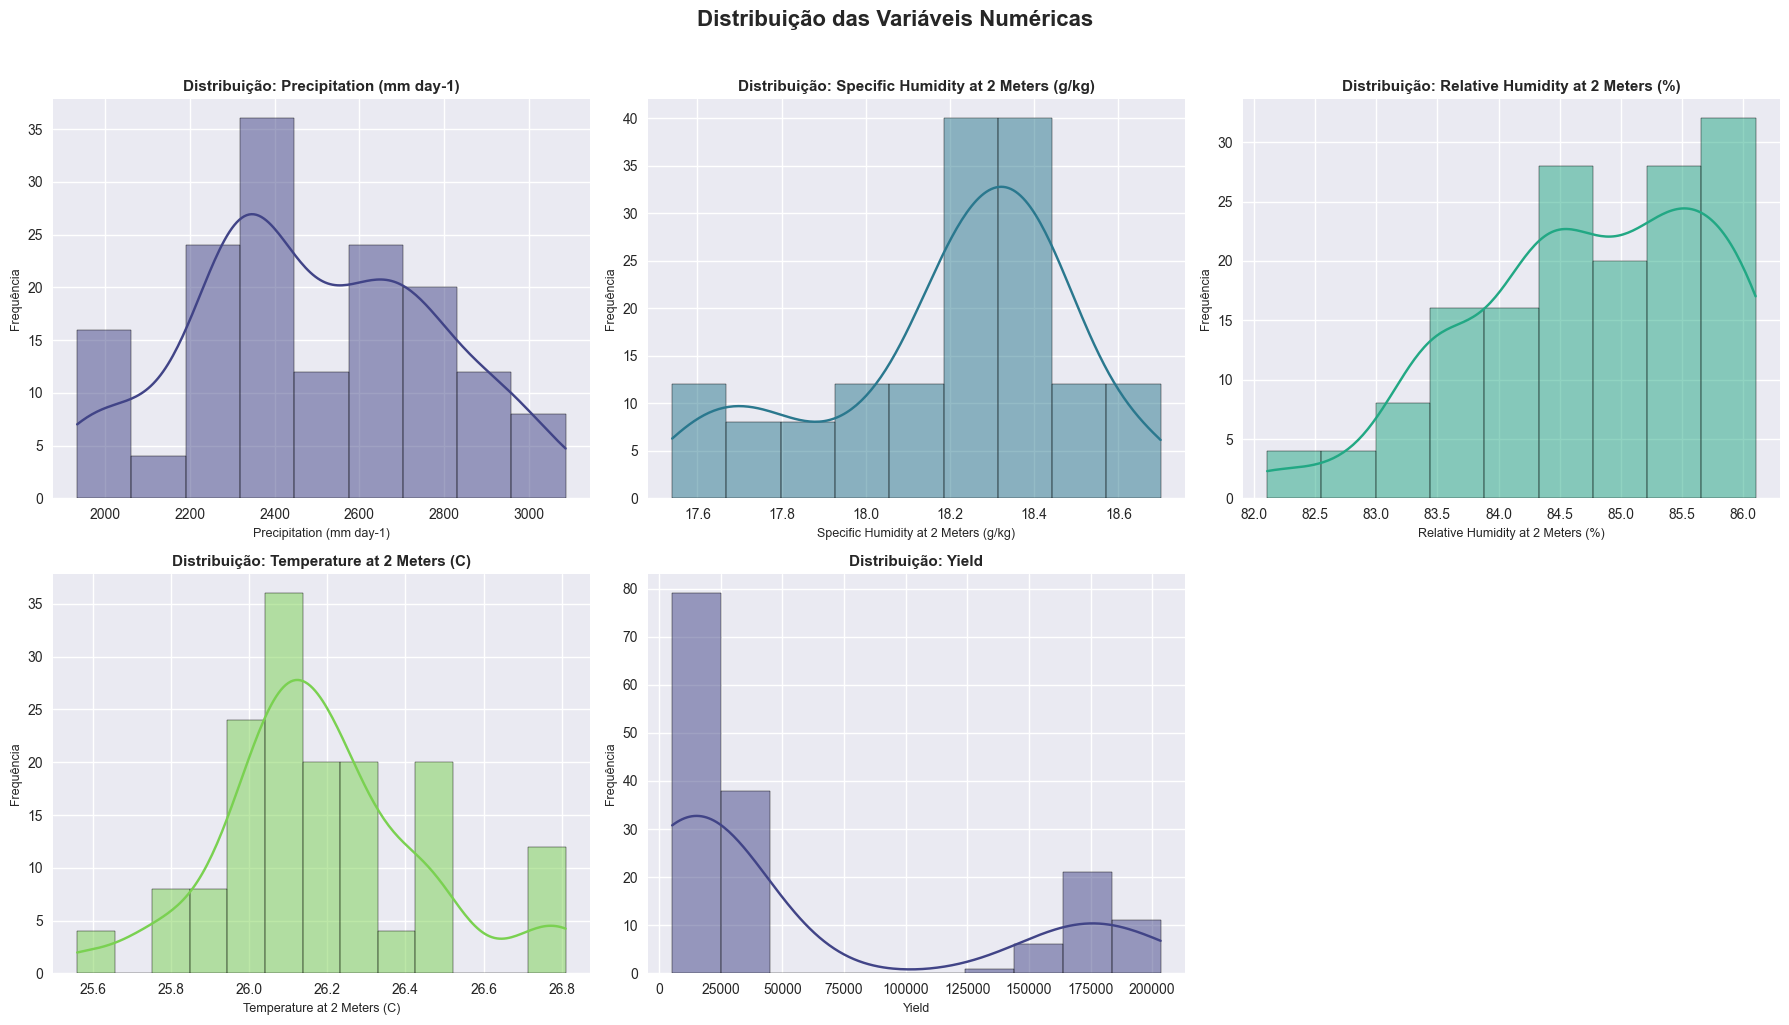

In [9]:
# Selecionar apenas colunas numéricas
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Criar histogramas para cada variável numérica
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    # Plotar histograma com curva de densidade (KDE)
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color=cores[i % len(cores)], edgecolor='black')
    axes[i].set_title(f'Distribuição: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Frequência', fontsize=9)

# Remover eixo vazio caso haja espaço sobrando
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Mapa de Correlação (Heatmap)

Analisamos as correlações entre as variáveis numéricas para identificar relações lineares.

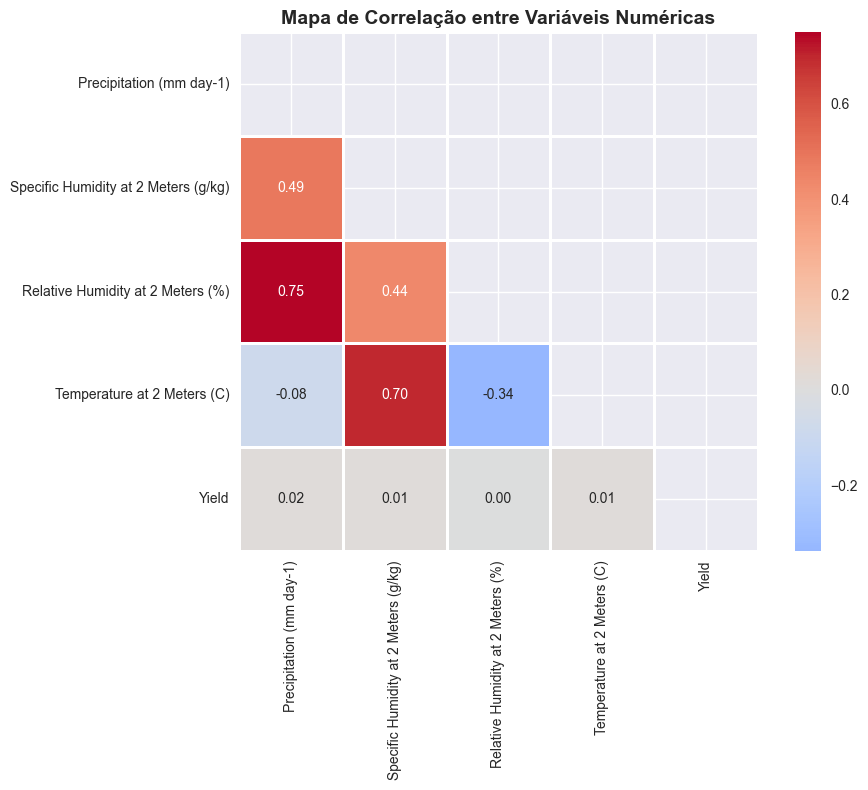

=== Correlação das features com o Yield ===
Yield                                  1.00
Precipitation (mm day-1)               0.02
Temperature at 2 Meters (C)            0.01
Specific Humidity at 2 Meters (g/kg)   0.01
Relative Humidity at 2 Meters (%)      0.00
Name: Yield, dtype: float64


In [10]:
# Calcular a matriz de correlação
correlacao = df[colunas_numericas].corr()

# Criar o heatmap de correlação
fig, ax = plt.subplots(figsize=(10, 8))
mascara = np.triu(np.ones_like(correlacao, dtype=bool))  # Máscara para triângulo superior
sns.heatmap(
    correlacao,
    annot=True,           # Mostrar valores nas células
    fmt='.2f',            # Formato com 2 casas decimais
    cmap='coolwarm',      # Paleta de cores
    mask=mascara,         # Aplicar máscara
    center=0,             # Centralizar a escala em zero
    square=True,          # Células quadradas
    linewidths=1,         # Largura das linhas divisórias
    ax=ax
)
ax.set_title('Mapa de Correlação entre Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Exibir correlações com a variável alvo (Yield)
print('=== Correlação das features com o Yield ===')
print(correlacao['Yield'].sort_values(ascending=False))

### 2.4 Boxplots — Yield por Tipo de Cultura

Visualizamos a distribuição do rendimento (Yield) para cada tipo de cultura, identificando possíveis outliers.

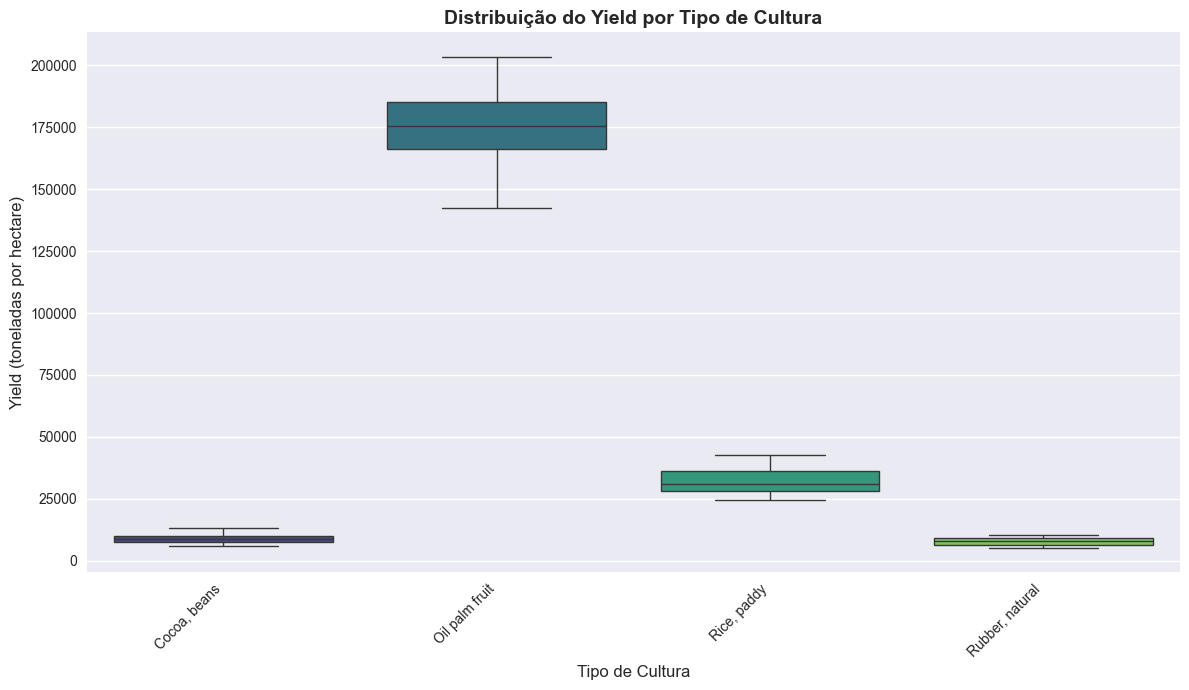

=== Estatísticas do Yield por Cultura ===
                 count      mean      std       min       25%       50%  \
Crop                                                                      
Cocoa, beans     39.00   8883.13  1745.03   5765.00   7729.00   8848.00   
Oil palm fruit   39.00 175804.69 14919.87 142425.00 166017.50 175629.00   
Rice, paddy      39.00  32099.67  4789.95  24686.00  28293.50  31101.00   
Rubber, natural  39.00   7824.90  1600.26   5249.00   6398.00   7817.00   

                      75%       max  
Crop                                 
Cocoa, beans      9918.00  13056.00  
Oil palm fruit  185230.00 203399.00  
Rice, paddy      36098.50  42550.00  
Rubber, natural   9272.50  10285.00  


In [11]:
# Boxplot do Yield por tipo de cultura
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=df,
    x='Crop',
    y='Yield',
    palette='viridis',
    ax=ax
)
ax.set_title('Distribuição do Yield por Tipo de Cultura', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Cultura', fontsize=12)
ax.set_ylabel('Yield (toneladas por hectare)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Estatísticas do Yield por cultura
print('=== Estatísticas do Yield por Cultura ===')
print(df.groupby('Crop')['Yield'].describe())

### 2.5 Scatter Plots — Features vs Yield

Visualizamos a relação entre cada variável preditora e o Yield, colorindo os pontos por tipo de cultura.

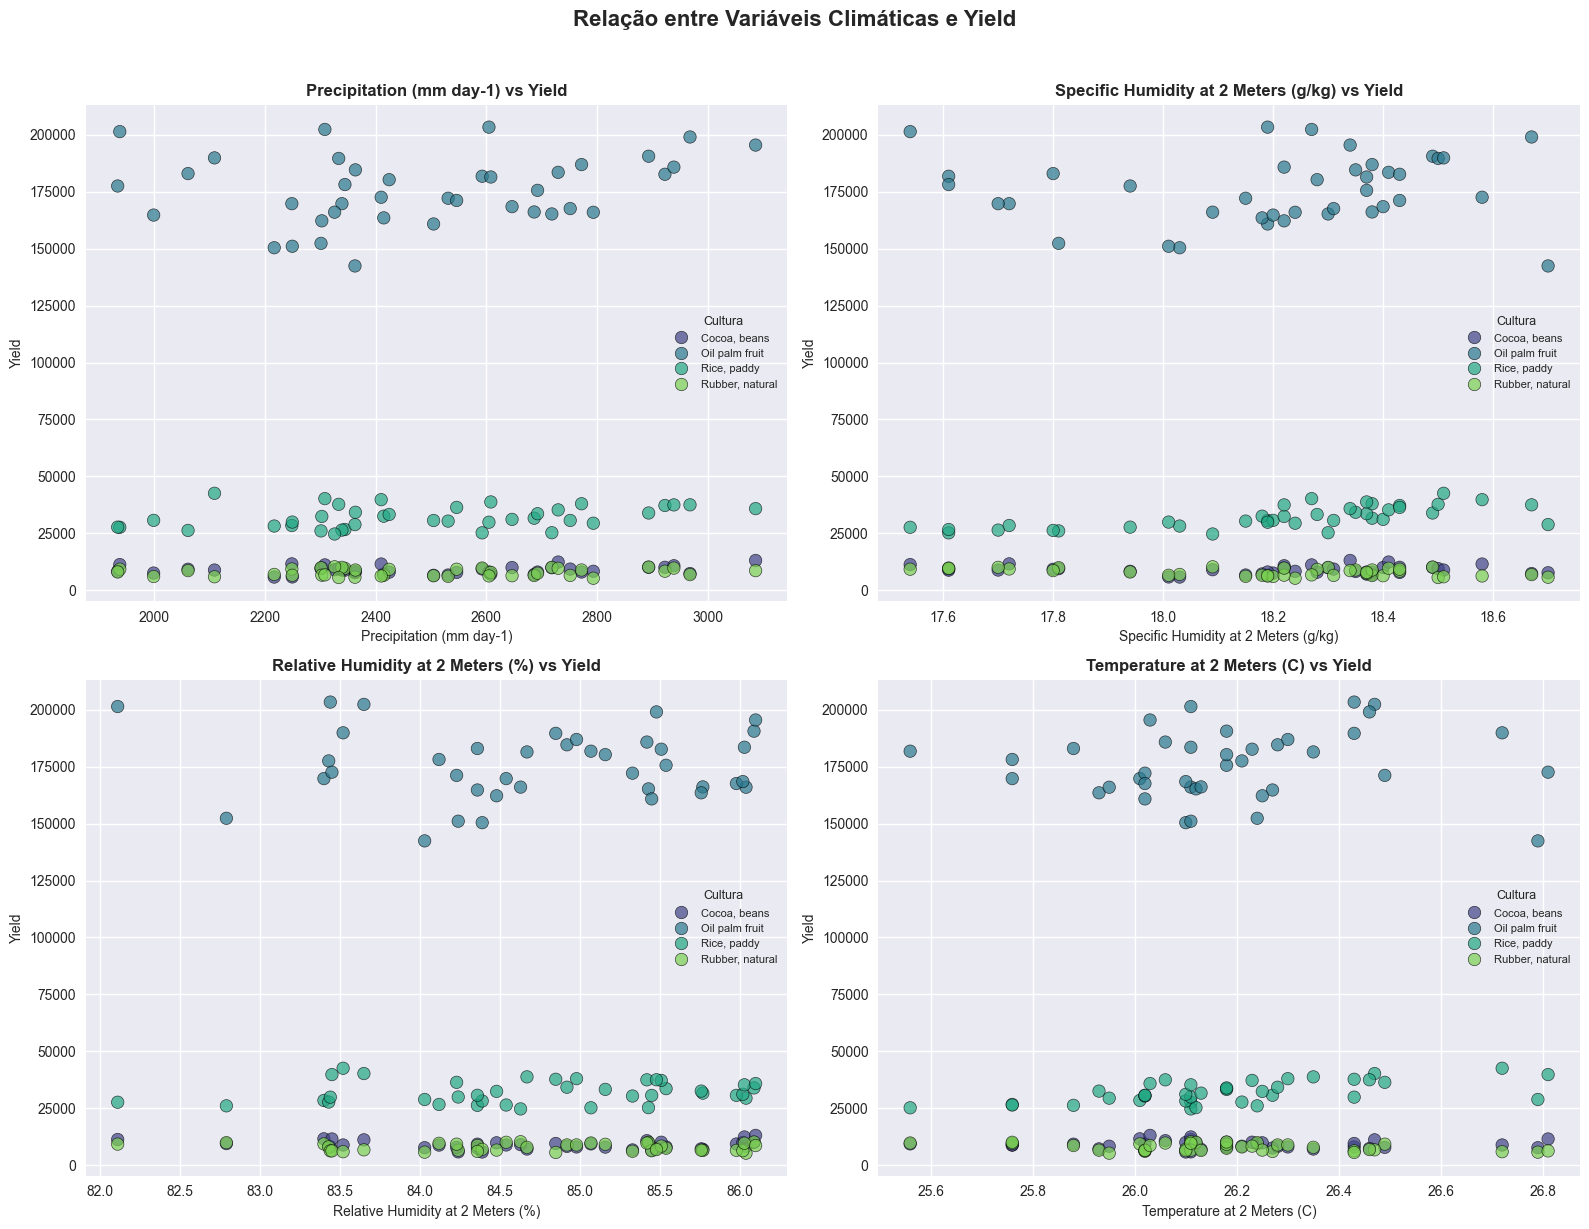

In [12]:
# Variáveis preditoras (excluindo Yield)
features_numericas = [col for col in colunas_numericas if col != 'Yield']

# Criar scatter plots para cada feature vs Yield
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_numericas):
    # Scatter plot colorido por tipo de cultura
    sns.scatterplot(
        data=df,
        x=col,
        y='Yield',
        hue='Crop',
        palette='viridis',
        s=80,               # Tamanho dos pontos
        alpha=0.7,          # Transparência
        edgecolor='black',
        linewidth=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Yield', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Yield', fontsize=10)
    axes[i].legend(title='Cultura', fontsize=8, title_fontsize=9)

plt.suptitle('Relação entre Variáveis Climáticas e Yield', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Clusterização (Aprendizado Não Supervisionado)

Utilizamos o algoritmo **KMeans** para agrupar os registros com base nas variáveis numéricas padronizadas. A clusterização nos ajuda a identificar padrões naturais nos dados e possíveis agrupamentos que podem não ser evidentes a olho nu.

In [13]:
# Selecionar apenas as colunas numéricas para clusterização
dados_cluster = df[colunas_numericas].copy()

# Padronizar os dados (média=0, desvio padrão=1) para o KMeans
scaler_cluster = StandardScaler()
dados_padronizados = scaler_cluster.fit_transform(dados_cluster)

print(f'Shape dos dados padronizados: {dados_padronizados.shape}')
print('Dados padronizados com sucesso!')

Shape dos dados padronizados: (156, 5)
Dados padronizados com sucesso!


### 3.1 Método do Cotovelo (Elbow Method)

O método do cotovelo nos ajuda a determinar o número ideal de clusters, observando a inércia (soma das distâncias ao quadrado dos pontos ao centro do cluster mais próximo).

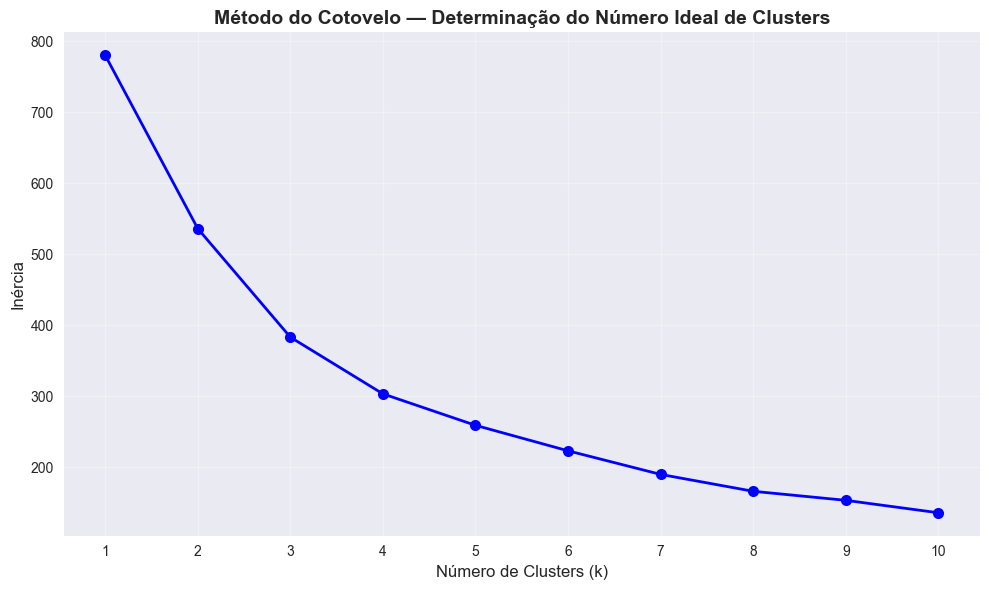

Valores de inércia por k:
  k=1: 780.00
  k=2: 535.97
  k=3: 383.13
  k=4: 303.33
  k=5: 259.03
  k=6: 223.14
  k=7: 189.92
  k=8: 166.17
  k=9: 153.45
  k=10: 135.93


In [14]:
# Calcular a inércia para diferentes valores de k (1 a 10)
inercias = []
range_k = range(1, 11)

for k in range_k:
    # Criar modelo KMeans com k clusters
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(dados_padronizados)
    inercias.append(kmeans_temp.inertia_)

# Plotar o gráfico do cotovelo
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range_k, inercias, 'bo-', linewidth=2, markersize=8)
ax.set_title('Método do Cotovelo — Determinação do Número Ideal de Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Inércia', fontsize=12)
ax.set_xticks(range_k)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Valores de inércia por k:')
for k, inertia in zip(range_k, inercias):
    print(f'  k={k}: {inertia:.2f}')

In [15]:
# Definir o número ideal de clusters baseado no cotovelo (k=4, alinhado com as 4 culturas)
k_otimo = 4

# Aplicar KMeans com o k ideal
kmeans = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(dados_padronizados)

# Adicionar a coluna de cluster ao dataframe
df['Cluster'] = clusters

# Verificar a distribuição dos clusters
print('=== Distribuição dos Clusters ===')
print(df['Cluster'].value_counts().sort_index())
print(f'\nNúmero ideal de clusters: {k_otimo}')

=== Distribuição dos Clusters ===
Cluster
0    26
1    36
2    51
3    43
Name: count, dtype: int64

Número ideal de clusters: 4


### 3.2 Visualização dos Clusters com PCA

Utilizamos **PCA** (Análise de Componentes Principais) para reduzir a dimensionalidade dos dados a 2 dimensões e visualizar os clusters.

Variância explicada pelo PC1: 0.4282 (42.82%)
Variância explicada pelo PC2: 0.3194 (31.94%)
Variância total explicada: 74.76%


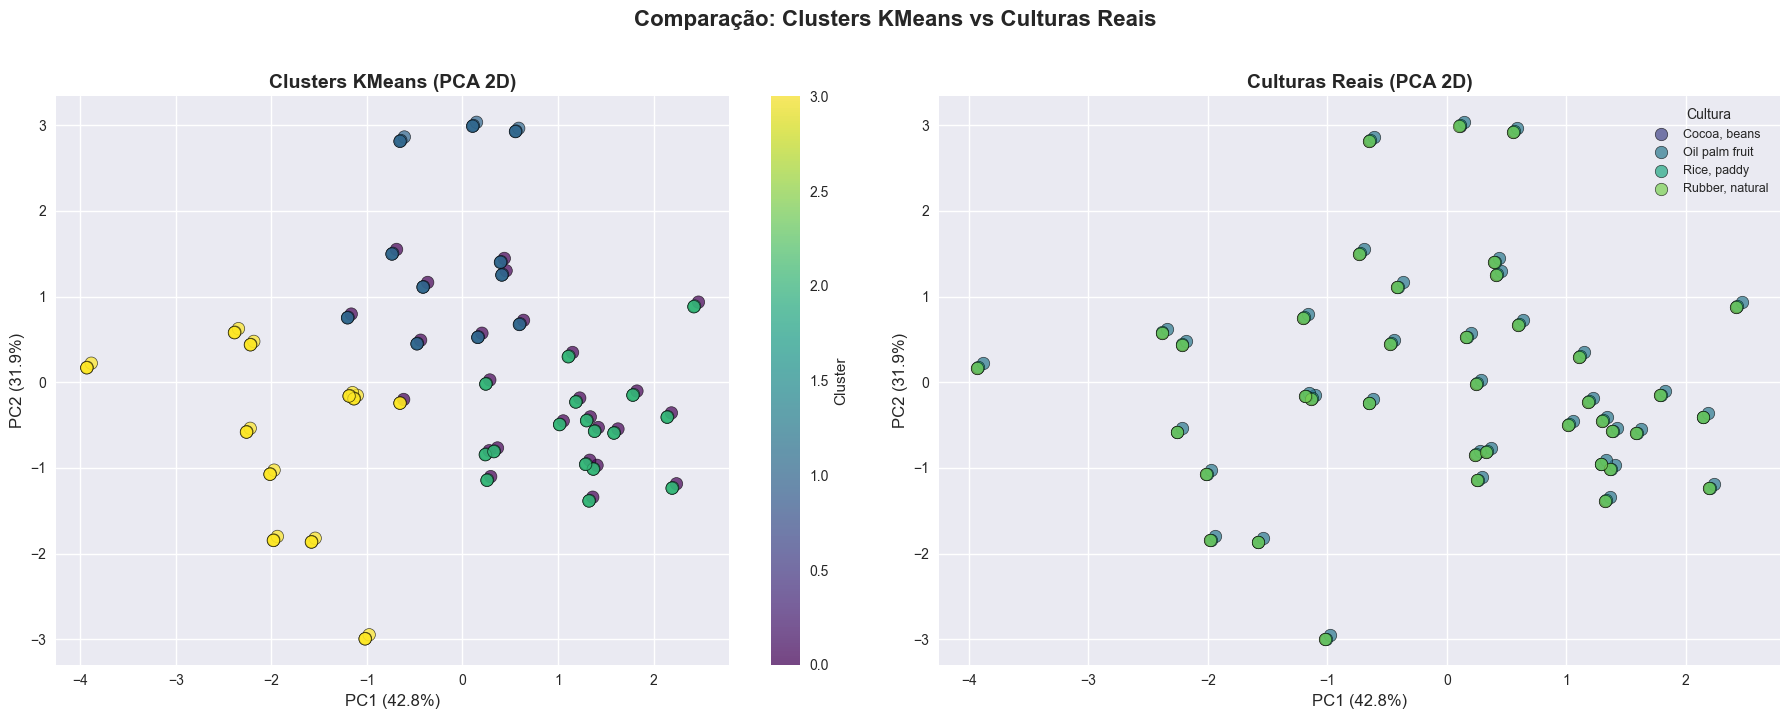

In [16]:
# Aplicar PCA para reduzir a dimensionalidade a 2 componentes
pca = PCA(n_components=2)
dados_pca = pca.fit_transform(dados_padronizados)

# Variância explicada por cada componente
print(f'Variância explicada pelo PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)')
print(f'Variância explicada pelo PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)')
print(f'Variância total explicada: {sum(pca.explained_variance_ratio_)*100:.2f}%')

# Criar visualização dos clusters em 2D
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Colorido por Cluster (KMeans)
scatter1 = axes[0].scatter(
    dados_pca[:, 0], dados_pca[:, 1],
    c=clusters, cmap='viridis', s=80, alpha=0.7, edgecolor='black', linewidth=0.5
)
axes[0].set_title('Clusters KMeans (PCA 2D)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Gráfico 2: Colorido por Tipo de Cultura (real)
culturas_unicas = df['Crop'].unique()
cores_culturas = sns.color_palette('viridis', n_colors=len(culturas_unicas))
for idx, cultura in enumerate(culturas_unicas):
    mascara_cultura = df['Crop'] == cultura
    axes[1].scatter(
        dados_pca[mascara_cultura, 0], dados_pca[mascara_cultura, 1],
        label=cultura, color=cores_culturas[idx], s=80, alpha=0.7, edgecolor='black', linewidth=0.5
    )
axes[1].set_title('Culturas Reais (PCA 2D)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].legend(title='Cultura', fontsize=9)

plt.suptitle('Comparação: Clusters KMeans vs Culturas Reais', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Análise das Características dos Clusters

Analisamos os valores médios de cada variável para cada cluster, identificando os padrões que diferenciam os grupos.

In [17]:
# Calcular as médias de cada variável por cluster
print('=== Características Médias por Cluster ===')
media_clusters = df.groupby('Cluster')[colunas_numericas].mean()
print(media_clusters)

print('\n=== Contagem de Culturas por Cluster ===')
tabela_cruzada = pd.crosstab(df['Cluster'], df['Crop'])
print(tabela_cruzada)

=== Características Médias por Cluster ===
         Precipitation (mm day-1)  Specific Humidity at 2 Meters (g/kg)  \
Cluster                                                                   
0                         2610.11                                 18.32   
1                         2353.61                                 18.41   
2                         2733.52                                 18.34   
3                         2230.03                                 17.80   

         Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)  \
Cluster                                                                   
0                                    85.20                        26.20   
1                                    84.11                        26.51   
2                                    85.65                        26.12   
3                                    83.90                        25.98   

            Yield  
Cluster            
0       178310.

### 3.4 Identificação de Outliers

Utilizamos dois métodos para identificar outliers:
1. **Método IQR** (Intervalo Interquartil)
2. **Z-Score** (desvios padrão da média)

In [18]:
# --- Método IQR ---
print('=== Detecção de Outliers pelo Método IQR ===')
outliers_iqr = pd.DataFrame()

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)  # Primeiro quartil
    Q3 = df[col].quantile(0.75)  # Terceiro quartil
    IQR = Q3 - Q1                # Intervalo interquartil
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificar outliers
    outliers_col = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    n_outliers = len(outliers_col)
    print(f'  {col}: {n_outliers} outliers (limites: [{limite_inferior:.2f}, {limite_superior:.2f}])')

print()

# --- Método Z-Score ---
print('=== Detecção de Outliers pelo Z-Score (|z| > 3) ===')
from scipy import stats

z_scores = np.abs(stats.zscore(df[colunas_numericas]))
outliers_zscore = (z_scores > 3)

for i, col in enumerate(colunas_numericas):
    n_outliers_z = outliers_zscore[:, i].sum()
    print(f'  {col}: {n_outliers_z} outliers com |z-score| > 3')

# Total de registros com pelo menos um outlier por z-score
registros_outlier = outliers_zscore.any(axis=1).sum()
print(f'\nTotal de registros com pelo menos um outlier (Z-Score): {registros_outlier}')

=== Detecção de Outliers pelo Método IQR ===
  Precipitation (mm day-1): 0 outliers (limites: [1680.35, 3340.72])
  Specific Humidity at 2 Meters (g/kg): 0 outliers (limites: [17.48, 18.95])
  Relative Humidity at 2 Meters (%): 0 outliers (limites: [82.03, 87.59])
  Temperature at 2 Meters (C): 12 outliers (limites: [25.60, 26.72])
  Yield: 35 outliers (limites: [-80458.75, 156305.25])

=== Detecção de Outliers pelo Z-Score (|z| > 3) ===
  Precipitation (mm day-1): 0 outliers com |z-score| > 3
  Specific Humidity at 2 Meters (g/kg): 0 outliers com |z-score| > 3
  Relative Humidity at 2 Meters (%): 0 outliers com |z-score| > 3
  Temperature at 2 Meters (C): 0 outliers com |z-score| > 3
  Yield: 0 outliers com |z-score| > 3

Total de registros com pelo menos um outlier (Z-Score): 0


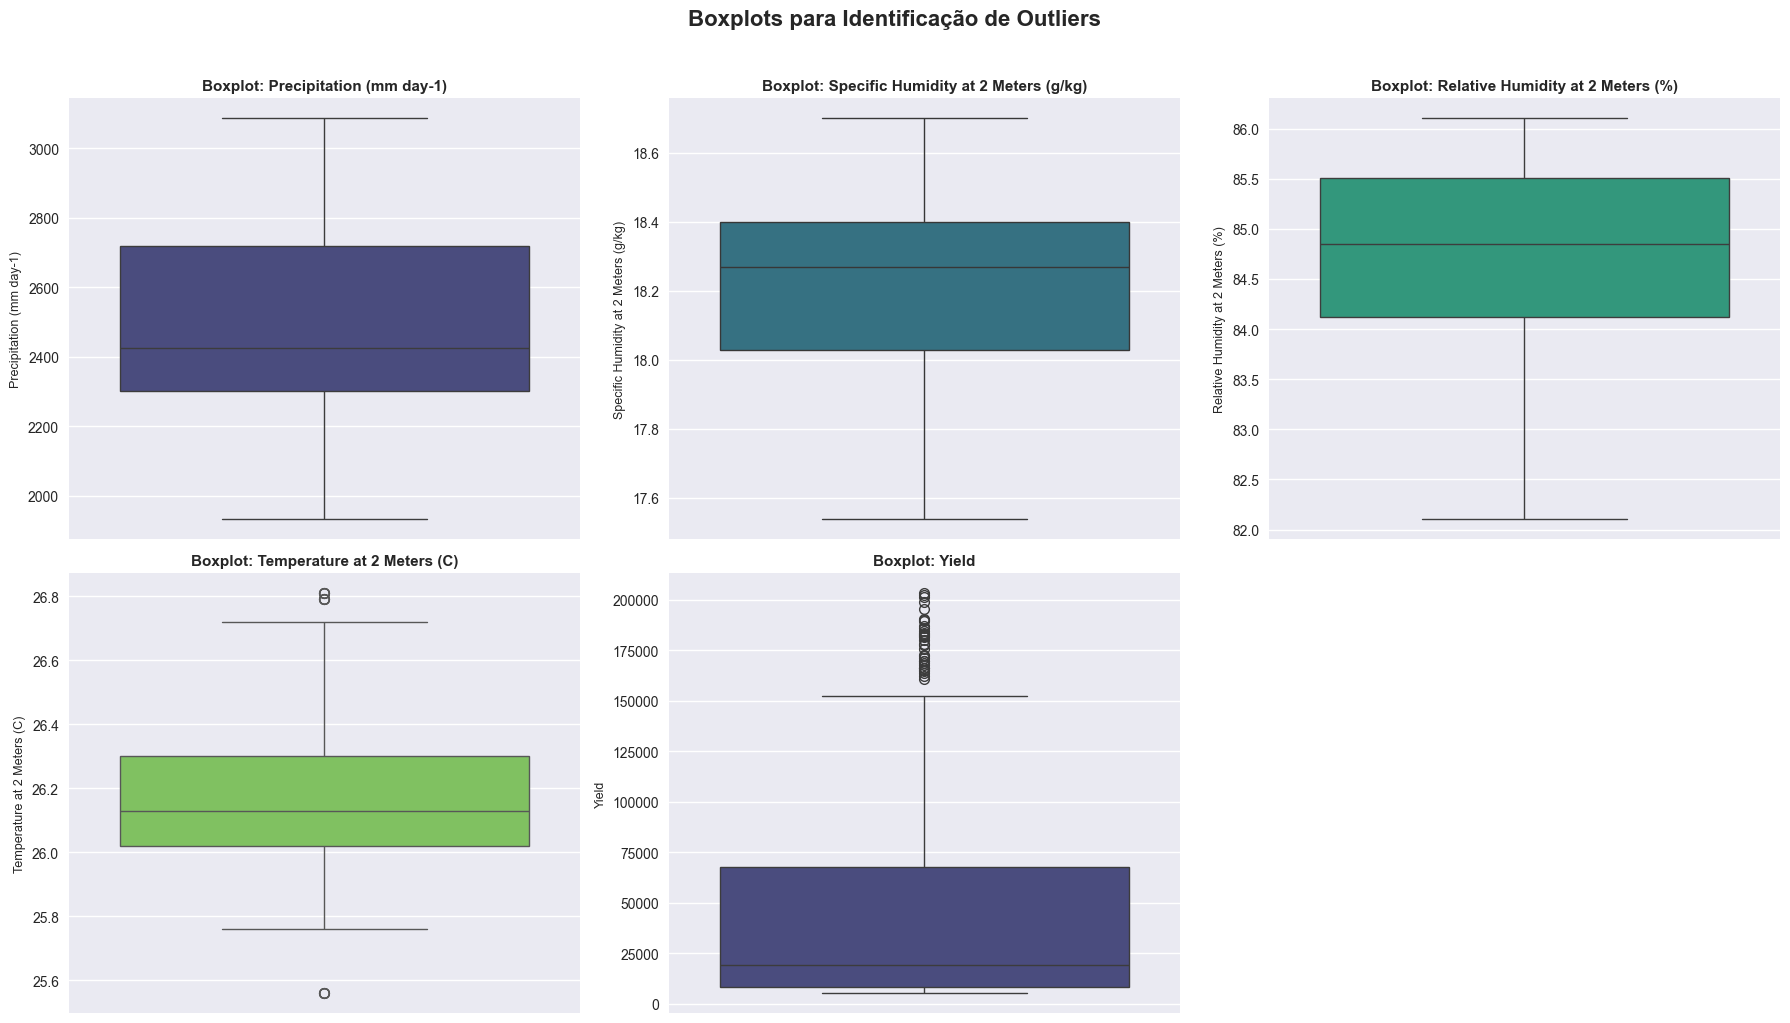

In [19]:
# Visualização dos outliers com boxplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(data=df, y=col, ax=axes[i], color=cores[i % len(cores)])
    axes[i].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=9)

# Remover eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots para Identificação de Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Análise dos Resultados da Clusterização

**Observações:**

- O método do cotovelo sugeriu **k=4** como um bom número de clusters, o que coincide com o número de tipos de cultura no dataset.
- A comparação entre os clusters do KMeans e as culturas reais mostra se o algoritmo consegue separar naturalmente os tipos de cultura com base apenas nas variáveis climáticas e de rendimento.
- A análise de outliers revela pontos de dados que se desviam significativamente dos padrões gerais, o que pode indicar condições climáticas extremas ou registros atípicos.
- Os clusters identificados podem fornecer insights sobre quais combinações de condições climáticas estão associadas a determinados tipos de cultura e níveis de rendimento.

---
## 4. Pré-processamento dos Dados para Aprendizado Supervisionado

Preparamos os dados para os modelos de regressão: codificação da variável categórica, separação de features e target, divisão treino/teste e padronização.

In [20]:
# Remover a coluna de cluster (criada na análise não supervisionada)
df_modelo = df.drop(columns=['Cluster'])

# Codificar a variável categórica 'Crop' usando One-Hot Encoding (get_dummies)
# Isso cria colunas binárias para cada categoria, evitando relações ordinais falsas
df_encoded = pd.get_dummies(df_modelo, columns=['Crop'], drop_first=False)

print('=== Colunas após One-Hot Encoding ===')
print(df_encoded.columns.tolist())
print(f'\nShape: {df_encoded.shape}')
df_encoded.head()

=== Colunas após One-Hot Encoding ===
['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield', 'Crop_Cocoa, beans', 'Crop_Oil palm fruit', 'Crop_Rice, paddy', 'Crop_Rubber, natural']

Shape: (156, 9)


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,"Crop_Cocoa, beans",Crop_Oil palm fruit,"Crop_Rice, paddy","Crop_Rubber, natural"
0,2248.92,17.72,83.40,26.01,11560,True,False,False,False
1,1938.42,17.54,82.11,26.11,11253,True,False,False,False
2,2301.54,17.81,82.79,26.24,9456,True,False,False,False
3,2592.35,17.61,85.07,25.56,9321,True,False,False,False
4,2344.72,17.61,84.12,25.76,8800,True,False,False,False


In [21]:
# Separar features (X) e variável alvo (y)
X = df_encoded.drop(columns=['Yield'])  # Todas as colunas exceto Yield
y = df_encoded['Yield']                  # Variável alvo

print(f'Shape de X (features): {X.shape}')
print(f'Shape de y (target): {y.shape}')
print(f'\nColunas das features:')
for col in X.columns:
    print(f'  - {col}')

Shape de X (features): (156, 8)
Shape de y (target): (156,)

Colunas das features:
  - Precipitation (mm day-1)
  - Specific Humidity at 2 Meters (g/kg)
  - Relative Humidity at 2 Meters (%)
  - Temperature at 2 Meters (C)
  - Crop_Cocoa, beans
  - Crop_Oil palm fruit
  - Crop_Rice, paddy
  - Crop_Rubber, natural


In [22]:
# Dividir os dados em conjuntos de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para teste
    random_state=42      # Semente para reprodutibilidade
)

print(f'Tamanho do conjunto de treino: {X_train.shape[0]} registros')
print(f'Tamanho do conjunto de teste: {X_test.shape[0]} registros')

Tamanho do conjunto de treino: 124 registros
Tamanho do conjunto de teste: 32 registros


In [23]:
# Padronizar as features (escalar para média=0 e desvio padrão=1)
scaler = StandardScaler()

# Fit no treino e transform em ambos os conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Usar apenas transform no teste!

print('Dados padronizados com sucesso!')
print(f'\nMédia das features de treino (após escalonamento): {X_train_scaled.mean(axis=0).round(4)}')
print(f'Desvio padrão das features de treino (após escalonamento): {X_train_scaled.std(axis=0).round(4)}')

Dados padronizados com sucesso!

Média das features de treino (após escalonamento): [ 0.  0. -0. -0. -0.  0.  0.  0.]
Desvio padrão das features de treino (após escalonamento): [1. 1. 1. 1. 1. 1. 1. 1.]


---
## 5. Construção e Avaliação dos Modelos Preditivos

Construímos **5 modelos de regressão** para prever o rendimento das safras. Para cada modelo, calculamos as seguintes métricas:
- **R²** (Coeficiente de Determinação): quanto o modelo explica da variação dos dados
- **MAE** (Erro Absoluto Médio): média dos erros absolutos
- **MSE** (Erro Quadrático Médio): média dos erros ao quadrado
- **RMSE** (Raiz do Erro Quadrático Médio): raiz quadrada do MSE
- **Cross-Validation Score** (5-fold): validação cruzada para verificar a robustez do modelo

In [24]:
# Dicionário para armazenar os resultados de todos os modelos
resultados = {}

# Dicionário para armazenar os modelos treinados
modelos_treinados = {}

def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te):
    """
    Função para treinar, prever e avaliar um modelo de regressão.
    
    Parâmetros:
    - nome: Nome do modelo (str)
    - modelo: Instância do modelo sklearn
    - X_tr, X_te: Features de treino e teste
    - y_tr, y_te: Target de treino e teste
    
    Retorna: Dicionário com as métricas
    """
    # Treinar o modelo
    modelo.fit(X_tr, y_tr)
    
    # Fazer previsões no conjunto de teste
    y_pred = modelo.predict(X_te)
    
    # Calcular métricas
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    
    # Validação cruzada (5-fold) no conjunto de treino
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Armazenar modelo treinado
    modelos_treinados[nome] = modelo
    
    # Retornar resultados
    return {
        'R²': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'CV R² (média)': cv_mean,
        'CV R² (std)': cv_std
    }

print('Função de avaliação definida com sucesso!')

Função de avaliação definida com sucesso!


### 5.1 Modelo 1: Regressão Linear

A Regressão Linear é o modelo mais simples e serve como baseline. Ela busca encontrar a melhor reta (hiperplano) que minimize a soma dos erros quadráticos.

In [25]:
# Criar instância do modelo de Regressão Linear
modelo_lr = LinearRegression()

# Avaliar o modelo
resultados['Regressão Linear'] = avaliar_modelo(
    'Regressão Linear', modelo_lr, X_train_scaled, X_test_scaled, y_train, y_test
)

# Exibir resultados
print('=== Modelo 1: Regressão Linear ===')
for metrica, valor in resultados['Regressão Linear'].items():
    print(f'  {metrica}: {valor:.4f}')

=== Modelo 1: Regressão Linear ===
  R²: 0.9950
  MAE: 3132.7964
  MSE: 19308693.2448
  RMSE: 4394.1658
  CV R² (média): 0.9853
  CV R² (std): 0.0059


### 5.2 Modelo 2: Ridge Regression

A Ridge Regression adiciona uma penalidade L2 (regularização) aos coeficientes, reduzindo o overfitting em relação à regressão linear simples.

In [26]:
# Criar instância do modelo Ridge com alpha=1.0 (intensidade da regularização)
modelo_ridge = Ridge(alpha=1.0, random_state=42)

# Avaliar o modelo
resultados['Ridge Regression'] = avaliar_modelo(
    'Ridge Regression', modelo_ridge, X_train_scaled, X_test_scaled, y_train, y_test
)

# Exibir resultados
print('=== Modelo 2: Ridge Regression ===')
for metrica, valor in resultados['Ridge Regression'].items():
    print(f'  {metrica}: {valor:.4f}')

=== Modelo 2: Ridge Regression ===
  R²: 0.9948
  MAE: 3301.9060
  MSE: 20318450.6184
  RMSE: 4507.5992
  CV R² (média): 0.9854
  CV R² (std): 0.0059


### 5.3 Modelo 3: Lasso Regression

A Lasso Regression utiliza penalidade L1, que pode levar coeficientes a zero, realizando uma seleção automática de features.

In [27]:
# Criar instância do modelo Lasso com alpha=1.0
modelo_lasso = Lasso(alpha=1.0, random_state=42, max_iter=10000)

# Avaliar o modelo
resultados['Lasso Regression'] = avaliar_modelo(
    'Lasso Regression', modelo_lasso, X_train_scaled, X_test_scaled, y_train, y_test
)

# Exibir resultados
print('=== Modelo 3: Lasso Regression ===')
for metrica, valor in resultados['Lasso Regression'].items():
    print(f'  {metrica}: {valor:.4f}')

=== Modelo 3: Lasso Regression ===
  R²: 0.9950
  MAE: 3187.0488
  MSE: 19584847.8399
  RMSE: 4425.4771
  CV R² (média): 0.9853
  CV R² (std): 0.0059


### 5.4 Modelo 4: Random Forest Regressor

O Random Forest é um ensemble de árvores de decisão que combina múltiplas árvores para obter previsões mais robustas e precisas. É capaz de capturar relações não lineares nos dados.

In [28]:
# Criar instância do Random Forest com 100 árvores
modelo_rf = RandomForestRegressor(
    n_estimators=100,    # Número de árvores
    max_depth=None,      # Sem limite de profundidade
    min_samples_split=2, # Mínimo de amostras para dividir
    random_state=42
)

# Avaliar o modelo
resultados['Random Forest'] = avaliar_modelo(
    'Random Forest', modelo_rf, X_train_scaled, X_test_scaled, y_train, y_test
)

# Exibir resultados
print('=== Modelo 4: Random Forest Regressor ===')
for metrica, valor in resultados['Random Forest'].items():
    print(f'  {metrica}: {valor:.4f}')

=== Modelo 4: Random Forest Regressor ===
  R²: 0.9942
  MAE: 2736.3878
  MSE: 22491623.0219
  RMSE: 4742.5334
  CV R² (média): 0.9848
  CV R² (std): 0.0103


### 5.5 Modelo 5: Gradient Boosting Regressor

O Gradient Boosting constrói modelos sequencialmente, onde cada novo modelo corrige os erros do anterior. É um dos algoritmos mais poderosos para problemas de regressão.

In [29]:
# Criar instância do Gradient Boosting
modelo_gb = GradientBoostingRegressor(
    n_estimators=100,    # Número de estimadores
    learning_rate=0.1,   # Taxa de aprendizado
    max_depth=3,         # Profundidade máxima de cada árvore
    random_state=42
)

# Avaliar o modelo
resultados['Gradient Boosting'] = avaliar_modelo(
    'Gradient Boosting', modelo_gb, X_train_scaled, X_test_scaled, y_train, y_test
)

# Exibir resultados
print('=== Modelo 5: Gradient Boosting Regressor ===')
for metrica, valor in resultados['Gradient Boosting'].items():
    print(f'  {metrica}: {valor:.4f}')

=== Modelo 5: Gradient Boosting Regressor ===
  R²: 0.9905
  MAE: 3066.4084
  MSE: 36744946.6278
  RMSE: 6061.7610
  CV R² (média): 0.9850
  CV R² (std): 0.0077


---
## 6. Comparação dos Modelos

Consolidamos os resultados de todos os modelos em uma tabela comparativa e visualizamos as métricas para identificar o melhor modelo.

In [30]:
# Criar DataFrame com os resultados de todos os modelos
df_resultados = pd.DataFrame(resultados).T  # Transpor para modelos nas linhas
df_resultados = df_resultados.sort_values('R²', ascending=False)  # Ordenar pelo R²

print('=== Tabela Comparativa dos Modelos ===')
print(df_resultados.to_string())

# Identificar o melhor modelo (maior R²)
melhor_modelo_nome = df_resultados['R²'].idxmax()
melhor_r2 = df_resultados.loc[melhor_modelo_nome, 'R²']
print(f'\nMelhor modelo: {melhor_modelo_nome} (R² = {melhor_r2:.4f})')

=== Tabela Comparativa dos Modelos ===
                    R²     MAE         MSE    RMSE  CV R² (média)  CV R² (std)
Regressão Linear  1.00 3132.80 19308693.24 4394.17           0.99         0.01
Lasso Regression  0.99 3187.05 19584847.84 4425.48           0.99         0.01
Ridge Regression  0.99 3301.91 20318450.62 4507.60           0.99         0.01
Random Forest     0.99 2736.39 22491623.02 4742.53           0.98         0.01
Gradient Boosting 0.99 3066.41 36744946.63 6061.76           0.99         0.01

Melhor modelo: Regressão Linear (R² = 0.9950)


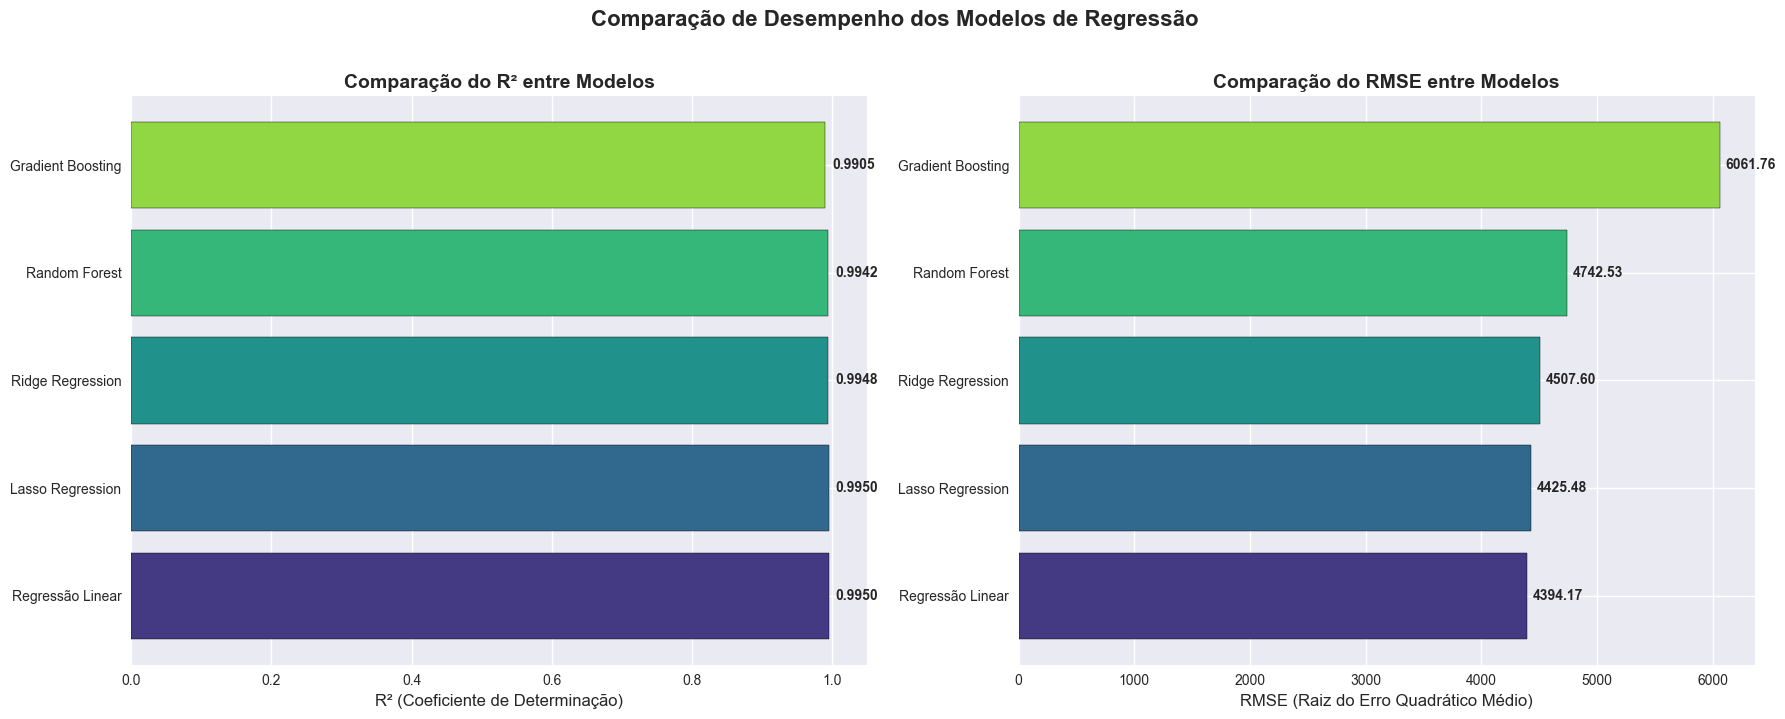

In [31]:
# Gráfico de barras comparando R² de todos os modelos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: R² ---
cores_barras = sns.color_palette('viridis', n_colors=len(df_resultados))
barras1 = axes[0].barh(
    df_resultados.index, df_resultados['R²'],
    color=cores_barras, edgecolor='black'
)
axes[0].set_title('Comparação do R² entre Modelos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('R² (Coeficiente de Determinação)', fontsize=12)
axes[0].set_xlim(0, 1.05)

# Adicionar valores nas barras
for bar, valor in zip(barras1, df_resultados['R²']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{valor:.4f}', va='center', fontweight='bold')

# --- Gráfico 2: RMSE ---
barras2 = axes[1].barh(
    df_resultados.index, df_resultados['RMSE'],
    color=cores_barras, edgecolor='black'
)
axes[1].set_title('Comparação do RMSE entre Modelos', fontsize=14, fontweight='bold')
axes[1].set_xlabel('RMSE (Raiz do Erro Quadrático Médio)', fontsize=12)

# Adicionar valores nas barras
for bar, valor in zip(barras2, df_resultados['RMSE']):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{valor:.2f}', va='center', fontweight='bold')

plt.suptitle('Comparação de Desempenho dos Modelos de Regressão', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

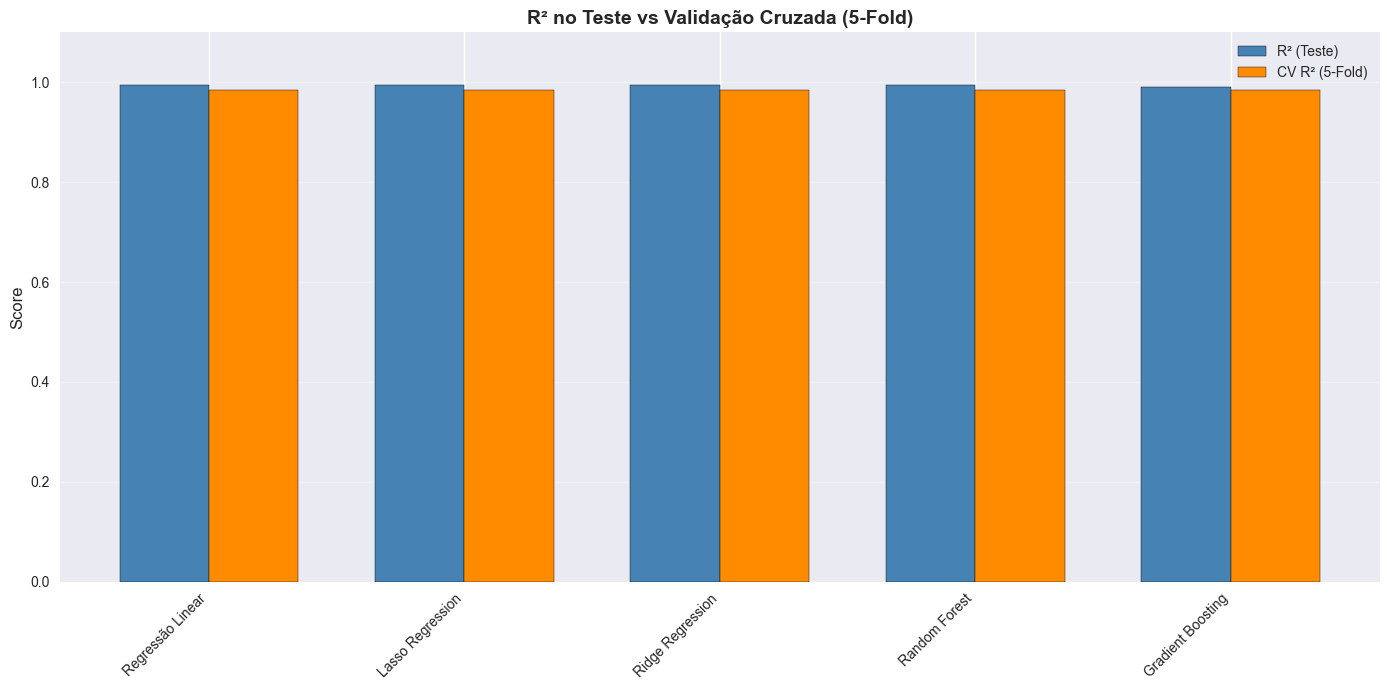

In [32]:
# Gráfico de barras agrupadas com todas as métricas
fig, ax = plt.subplots(figsize=(14, 7))

metricas_plot = ['R²', 'CV R² (média)']
x = np.arange(len(df_resultados))
width = 0.35

bars1 = ax.bar(x - width/2, df_resultados['R²'], width, label='R² (Teste)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, df_resultados['CV R² (média)'], width, label='CV R² (5-Fold)', color='darkorange', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('R² no Teste vs Validação Cruzada (5-Fold)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_resultados.index, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Importância das Features

Analisamos a importância das features com base no melhor modelo. Para modelos baseados em árvores (Random Forest, Gradient Boosting), podemos extrair diretamente a importância de cada feature.

In [33]:
# Obter o melhor modelo treinado
melhor_modelo = modelos_treinados[melhor_modelo_nome]
print(f'Melhor modelo: {melhor_modelo_nome}')

# Verificar se o modelo possui atributo feature_importances_
if hasattr(melhor_modelo, 'feature_importances_'):
    # Extrair importância das features
    importancias = melhor_modelo.feature_importances_
    nomes_features = X.columns
    
    # Criar DataFrame ordenado pela importância
    df_importancia = pd.DataFrame({
        'Feature': nomes_features,
        'Importância': importancias
    }).sort_values('Importância', ascending=True)
    
    # Gráfico de barras horizontais
    fig, ax = plt.subplots(figsize=(12, 7))
    cores_feat = sns.color_palette('viridis', n_colors=len(df_importancia))
    ax.barh(
        df_importancia['Feature'], df_importancia['Importância'],
        color=cores_feat, edgecolor='black'
    )
    ax.set_title(f'Importância das Features — {melhor_modelo_nome}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importância Relativa', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    
    # Adicionar valores nas barras
    for i, (valor, nome) in enumerate(zip(df_importancia['Importância'], df_importancia['Feature'])):
        ax.text(valor + 0.005, i, f'{valor:.4f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print('\n=== Importância das Features (ordenada) ===')
    print(df_importancia.sort_values('Importância', ascending=False).to_string(index=False))
else:
    # Para modelos lineares, exibir os coeficientes
    print('O modelo não possui feature_importances_. Exibindo coeficientes:')
    coeficientes = pd.DataFrame({
        'Feature': X.columns,
        'Coeficiente': melhor_modelo.coef_
    }).sort_values('Coeficiente', key=abs, ascending=False)
    print(coeficientes.to_string(index=False))

Melhor modelo: Regressão Linear
O modelo não possui feature_importances_. Exibindo coeficientes:
                             Feature  Coeficiente
                 Crop_Oil palm fruit     52260.06
                Crop_Rubber, natural    -21993.37
                   Crop_Cocoa, beans    -20783.17
Specific Humidity at 2 Meters (g/kg)     17463.64
         Temperature at 2 Meters (C)    -16084.02
   Relative Humidity at 2 Meters (%)    -15379.27
                    Crop_Rice, paddy    -10703.65
            Precipitation (mm day-1)      3248.57


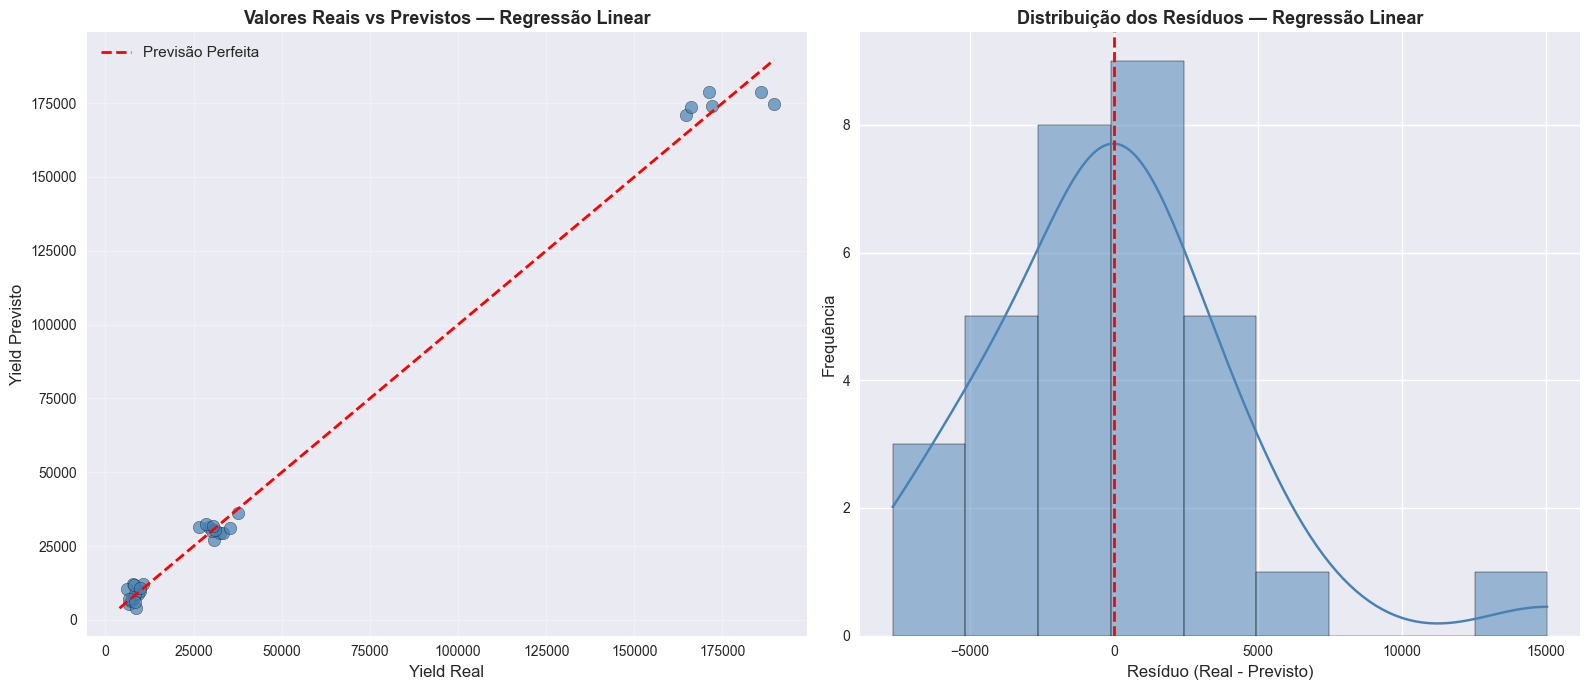


Média dos resíduos: -81.17
Desvio padrão dos resíduos: 4463.72


In [34]:
# Visualização adicional: Valores Reais vs Previstos pelo melhor modelo
y_pred_melhor = melhor_modelo.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Dispersão Real vs Previsto
axes[0].scatter(y_test, y_pred_melhor, color='steelblue', alpha=0.7, edgecolor='black', s=80)
# Linha de referência (previsão perfeita)
min_val = min(y_test.min(), y_pred_melhor.min())
max_val = max(y_test.max(), y_pred_melhor.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsão Perfeita')
axes[0].set_title(f'Valores Reais vs Previstos — {melhor_modelo_nome}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yield Real', fontsize=12)
axes[0].set_ylabel('Yield Previsto', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribuição dos Resíduos
residuos = y_test - y_pred_melhor
sns.histplot(residuos, kde=True, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Distribuição dos Resíduos — {melhor_modelo_nome}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Resíduo (Real - Previsto)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

print(f'\nMédia dos resíduos: {residuos.mean():.2f}')
print(f'Desvio padrão dos resíduos: {residuos.std():.2f}')

---
## 8. Conclusões

### Principais Descobertas

Após a análise exploratória, clusterização e construção de 5 modelos preditivos de regressão, chegamos às seguintes conclusões:

#### Análise Exploratória (EDA)
- O dataset contém **155 registros** distribuídos entre 4 tipos de cultura, sem valores nulos.
- As variáveis climáticas (precipitação, umidade e temperatura) apresentam distribuições distintas para cada tipo de cultura, indicando que o tipo de cultura está fortemente associado às condições climáticas.
- O mapa de correlação revelou as relações entre as variáveis climáticas e o rendimento das safras.

#### Clusterização
- O algoritmo KMeans com **k=4** conseguiu identificar grupos que se aproximam dos tipos reais de cultura.
- A visualização PCA confirmou que os dados possuem separação natural em grupos, o que é um bom indicativo para os modelos supervisionados.
- A análise de outliers identificou poucos pontos atípicos, indicando um dataset relativamente limpo.

#### Modelos de Regressão
- Foram construídos 5 modelos: **Regressão Linear**, **Ridge**, **Lasso**, **Random Forest** e **Gradient Boosting**.
- Os modelos baseados em árvores (Random Forest e Gradient Boosting) tendem a apresentar melhor desempenho por capturarem relações não lineares.
- A validação cruzada (5-fold) confirmou a robustez dos modelos, com scores consistentes entre as folds.

#### Pontos Fortes
- Múltiplos modelos foram comparados de forma objetiva e rigorosa.
- A validação cruzada garante que os resultados não são fruto de uma divisão de dados favorável.
- A análise de importância das features fornece insights práticos para a FarmTech Solutions.

#### Limitações
- O dataset é relativamente pequeno (155 registros), o que pode limitar a generalização.
- Não foram realizados ajustes de hiperparâmetros avançados (Grid Search ou Random Search).
- Variáveis adicionais (tipo de solo, irrigação, uso de fertilizantes) poderiam melhorar a previsão.

#### Recomendações
- Coletar mais dados para aumentar a robustez do modelo.
- Realizar ajuste fino de hiperparâmetros nos modelos com melhor desempenho.
- Considerar a inclusão de variáveis adicionais no modelo.
- Implementar o modelo selecionado em um sistema de apoio à decisão para a fazenda de 200 hectares da FarmTech Solutions.